In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [6]:
# Cell 2+3 Combined: Upload + Load in one step
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()  # Click "Choose Files" → select Quarterly_results.xlsx

# Get the filename from what was uploaded
filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")

# Load directly from memory (no file path needed)
xl_bytes = io.BytesIO(uploaded[filename])

df_dabur  = pd.read_excel(xl_bytes, sheet_name=0)
xl_bytes.seek(0)
df_hul    = pd.read_excel(xl_bytes, sheet_name=1)
xl_bytes.seek(0)
df_marico = pd.read_excel(xl_bytes, sheet_name=2)
xl_bytes.seek(0)
df_seg    = pd.read_excel(xl_bytes, sheet_name=3)
xl_bytes.seek(0)
df_notes  = pd.read_excel(xl_bytes, sheet_name=4)

print("✅ All sheets loaded")

Saving Quarterly results.xlsx to Quarterly results (2).xlsx
Uploaded: Quarterly results (2).xlsx
✅ All sheets loaded


In [8]:
# Cell 4 (Fixed): Quarter already parsed as datetime — just format it
def fix_quarter(df):
    df = df.copy()
    df['Quarter'] = pd.to_datetime(df['Quarter']).dt.strftime('%b-%Y')
    return df

df_dabur  = fix_quarter(df_dabur)
df_hul    = fix_quarter(df_hul)
df_marico = fix_quarter(df_marico)

print("✅ Dates fixed")
print(df_dabur['Quarter'].tolist())

✅ Dates fixed
['Mar-2023', 'Jun-2023', 'Sep-2023', 'Dec-2023', 'Mar-2024', 'Jun-2024', 'Sep-2024', 'Dec-2024', 'Mar-2025', 'Jun-2025', 'Sep-2025', 'Dec-2025', 'Mar-2026']


In [9]:
# Cell 5: Quick sanity check
for name, df in [("Dabur", df_dabur), ("HUL", df_hul),
                 ("Marico", df_marico), ("Segments", df_seg),
                 ("ConcallNotes", df_notes)]:
    print(f"\n── {name} ── {df.shape}")
    print(df.head(3).to_string(index=False))


── Dabur ── (13, 6)
 Quarter  Sales  Expenses  Operating Profit  OPM_pct  Net Profit
Mar-2023   2678      2268               410       15         293
Jun-2023   3130      2526               605       19         457
Sep-2023   3204      2543               661       21         507

── HUL ── (13, 6)
 Quarter  Sales  Expenses  Operating Profit  OPM_pct  Net Profit
Mar-2023  15215     11643              3572       23        2601
Jun-2023  15496     11832              3664       24        2556
Sep-2023  15623     11828              3795       24        2657

── Marico ── (13, 6)
 Quarter  Sales  Expenses  Operating Profit  OPM_pct  Net Profit
Mar-2023   2240      1847               393       18         305
Jun-2023   2477      1903               574       23         436
Sep-2023   2476      1979               497       20         360

── Segments ── (5, 7)
    FY  ConsumerCare_Cr  Foods_Cr  Others_Cr  Total_Revenue_Cr  Foods_pct  Others_pct
FY2021          6185.23    889.61      94.43     

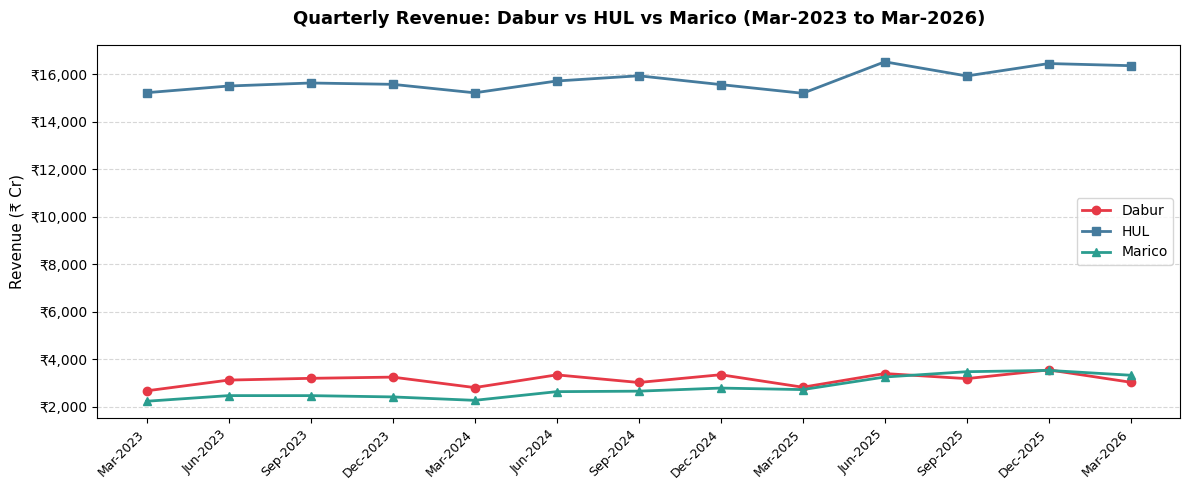

✅ Chart saved as revenue_trend.png


In [10]:
# Cell 6: Revenue Growth Trend — Dabur vs HUL vs Marico
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_dabur['Quarter'],  df_dabur['Sales'],  marker='o', label='Dabur',  color='#E63946', linewidth=2)
ax.plot(df_hul['Quarter'],    df_hul['Sales'],    marker='s', label='HUL',    color='#457B9D', linewidth=2)
ax.plot(df_marico['Quarter'], df_marico['Sales'], marker='^', label='Marico', color='#2A9D8F', linewidth=2)

# Rotate x-axis labels
ax.set_xticks(range(len(df_dabur['Quarter'])))
ax.set_xticklabels(df_dabur['Quarter'], rotation=45, ha='right', fontsize=9)

ax.set_title('Quarterly Revenue: Dabur vs HUL vs Marico (Mar-2023 to Mar-2026)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Revenue (₹ Cr)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as revenue_trend.png")

In [11]:
# Cell 7: Revenue Growth % — First vs Last quarter comparison
companies = {
    'Dabur':  df_dabur,
    'HUL':    df_hul,
    'Marico': df_marico
}

print("=" * 55)
print(f"{'Company':<10} {'Mar-2023 (₹Cr)':>16} {'Mar-2026 (₹Cr)':>16} {'Growth %':>10}")
print("=" * 55)

for name, df in companies.items():
    start = df.iloc[0]['Sales']
    end   = df.iloc[-1]['Sales']
    growth = ((end - start) / start) * 100
    print(f"{name:<10} {start:>16,.0f} {end:>16,.0f} {growth:>9.1f}%")

print("=" * 55)

# Also print YoY for Dabur's last 4 quarters
print("\nDabur — Last 4 Quarters YoY Revenue Growth:")
print("-" * 45)
for i in range(9, 13):   # indices 9–12 = Jun-2025 to Mar-2026
    curr = df_dabur.iloc[i]['Sales']
    prev = df_dabur.iloc[i - 4]['Sales']   # same quarter prior year
    yoy  = ((curr - prev) / prev) * 100
    print(f"  {df_dabur.iloc[i]['Quarter']}:  ₹{curr:,.0f} Cr  |  YoY: {yoy:+.1f}%")

Company      Mar-2023 (₹Cr)   Mar-2026 (₹Cr)   Growth %
Dabur                 2,678            3,038      13.4%
HUL                  15,215           16,351       7.5%
Marico                2,240            3,333      48.8%

Dabur — Last 4 Quarters YoY Revenue Growth:
---------------------------------------------
  Jun-2025:  ₹3,405 Cr  |  YoY: +1.7%
  Sep-2025:  ₹3,191 Cr  |  YoY: +5.3%
  Dec-2025:  ₹3,559 Cr  |  YoY: +6.1%
  Mar-2026:  ₹3,038 Cr  |  YoY: +7.3%


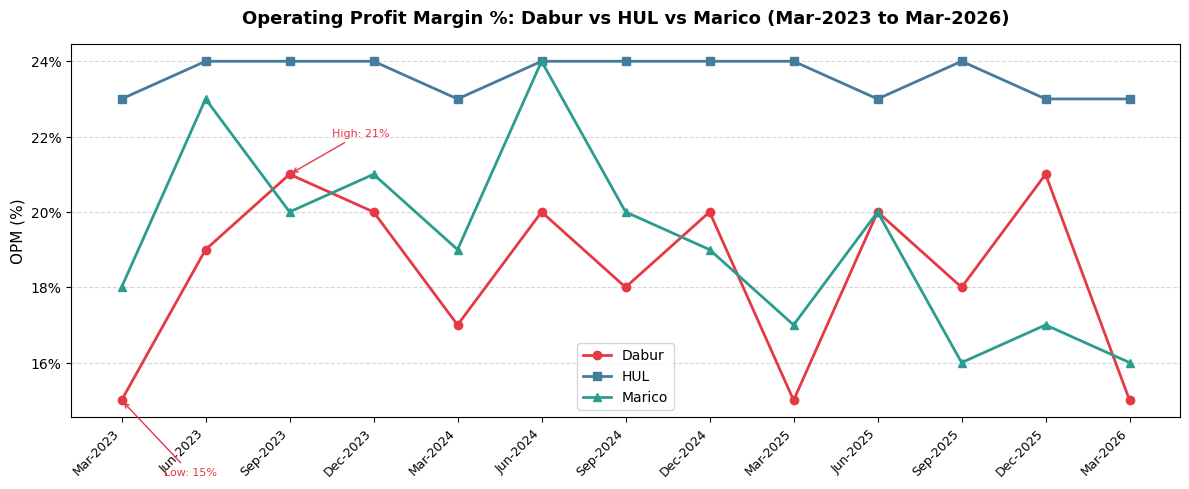


OPM Summary Statistics:
----------------------------------------
Dabur       Avg: 18.4%  |  Min: 15%  |  Max: 21%  |  Range: 6%
HUL         Avg: 23.6%  |  Min: 23%  |  Max: 24%  |  Range: 1%
Marico      Avg: 19.2%  |  Min: 16%  |  Max: 24%  |  Range: 8%


In [12]:
# Cell 8: Operating Margin Comparison — Dabur vs HUL vs Marico
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_dabur['Quarter'],  df_dabur['OPM_pct'],  marker='o', label='Dabur',  color='#E63946', linewidth=2)
ax.plot(df_hul['Quarter'],    df_hul['OPM_pct'],    marker='s', label='HUL',    color='#457B9D', linewidth=2)
ax.plot(df_marico['Quarter'], df_marico['OPM_pct'], marker='^', label='Marico', color='#2A9D8F', linewidth=2)

ax.set_xticks(range(len(df_dabur['Quarter'])))
ax.set_xticklabels(df_dabur['Quarter'], rotation=45, ha='right', fontsize=9)

ax.set_title('Operating Profit Margin %: Dabur vs HUL vs Marico (Mar-2023 to Mar-2026)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('OPM (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate Dabur's min and max
dabur_min_idx = df_dabur['OPM_pct'].idxmin()
dabur_max_idx = df_dabur['OPM_pct'].idxmax()
ax.annotate(f"Low: {df_dabur.loc[dabur_min_idx,'OPM_pct']}%",
            xy=(dabur_min_idx, df_dabur.loc[dabur_min_idx,'OPM_pct']),
            xytext=(dabur_min_idx+0.5, df_dabur.loc[dabur_min_idx,'OPM_pct']-2),
            fontsize=8, color='#E63946',
            arrowprops=dict(arrowstyle='->', color='#E63946'))
ax.annotate(f"High: {df_dabur.loc[dabur_max_idx,'OPM_pct']}%",
            xy=(dabur_max_idx, df_dabur.loc[dabur_max_idx,'OPM_pct']),
            xytext=(dabur_max_idx+0.5, df_dabur.loc[dabur_max_idx,'OPM_pct']+1),
            fontsize=8, color='#E63946',
            arrowprops=dict(arrowstyle='->', color='#E63946'))

plt.tight_layout()
plt.savefig('opm_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print("\nOPM Summary Statistics:")
print("-" * 40)
for name, df in [("Dabur", df_dabur), ("HUL", df_hul), ("Marico", df_marico)]:
    print(f"{name:<10}  Avg: {df['OPM_pct'].mean():.1f}%  |  Min: {df['OPM_pct'].min()}%  |  Max: {df['OPM_pct'].max()}%  |  Range: {df['OPM_pct'].max()-df['OPM_pct'].min()}%")

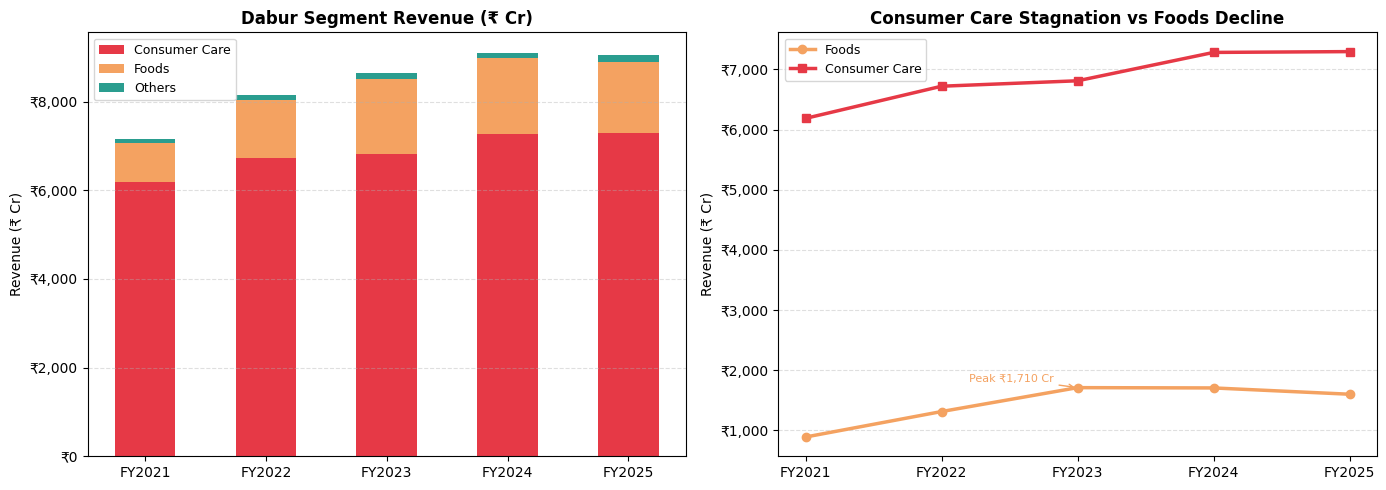


Dabur Segment Revenue Summary:
    FY  ConsumerCare_Cr  Foods_Cr  Total_Revenue_Cr  Foods_pct
FY2021          6185.23    889.61           7184.73       12.4
FY2022          6719.70   1312.80           8179.50       16.0
FY2023          6809.98   1710.07           8684.35       19.7
FY2024          7281.46   1705.25           9135.60       18.7
FY2025          7295.00   1600.54           9070.71       17.6


In [13]:
# Cell 9: Segment Revenue Trend — Consumer Care vs Foods vs Others
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Absolute revenue by segment (stacked bar) ---
ax1 = axes[0]
x = range(len(df_seg['FY']))
width = 0.5

bars1 = ax1.bar(x, df_seg['ConsumerCare_Cr'], width, label='Consumer Care', color='#E63946')
bars2 = ax1.bar(x, df_seg['Foods_Cr'],        width, bottom=df_seg['ConsumerCare_Cr'], label='Foods', color='#F4A261')
bars3 = ax1.bar(x, df_seg['Others_Cr'],       width,
                bottom=df_seg['ConsumerCare_Cr'] + df_seg['Foods_Cr'], label='Others', color='#2A9D8F')

ax1.set_xticks(x)
ax1.set_xticklabels(df_seg['FY'], fontsize=10)
ax1.set_title("Dabur Segment Revenue (₹ Cr)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Revenue (₹ Cr)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Right: Foods segment trend (line) to show peak & decline ---
ax2 = axes[1]
ax2.plot(df_seg['FY'], df_seg['Foods_Cr'], marker='o', color='#F4A261', linewidth=2.5, label='Foods')
ax2.plot(df_seg['FY'], df_seg['ConsumerCare_Cr'], marker='s', color='#E63946', linewidth=2.5, label='Consumer Care')

ax2.set_title("Consumer Care Stagnation vs Foods Decline", fontsize=12, fontweight='bold')
ax2.set_ylabel("Revenue (₹ Cr)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# Annotate Foods peak
peak_idx = df_seg['Foods_Cr'].idxmax()
ax2.annotate(f"Peak ₹{df_seg.loc[peak_idx,'Foods_Cr']:,.0f} Cr",
             xy=(peak_idx, df_seg.loc[peak_idx,'Foods_Cr']),
             xytext=(peak_idx - 0.8, df_seg.loc[peak_idx,'Foods_Cr'] + 100),
             fontsize=8, color='#F4A261',
             arrowprops=dict(arrowstyle='->', color='#F4A261'))

plt.tight_layout()
plt.savefig('segment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Print segment table
print("\nDabur Segment Revenue Summary:")
print(df_seg[['FY','ConsumerCare_Cr','Foods_Cr','Total_Revenue_Cr','Foods_pct']].to_string(index=False))

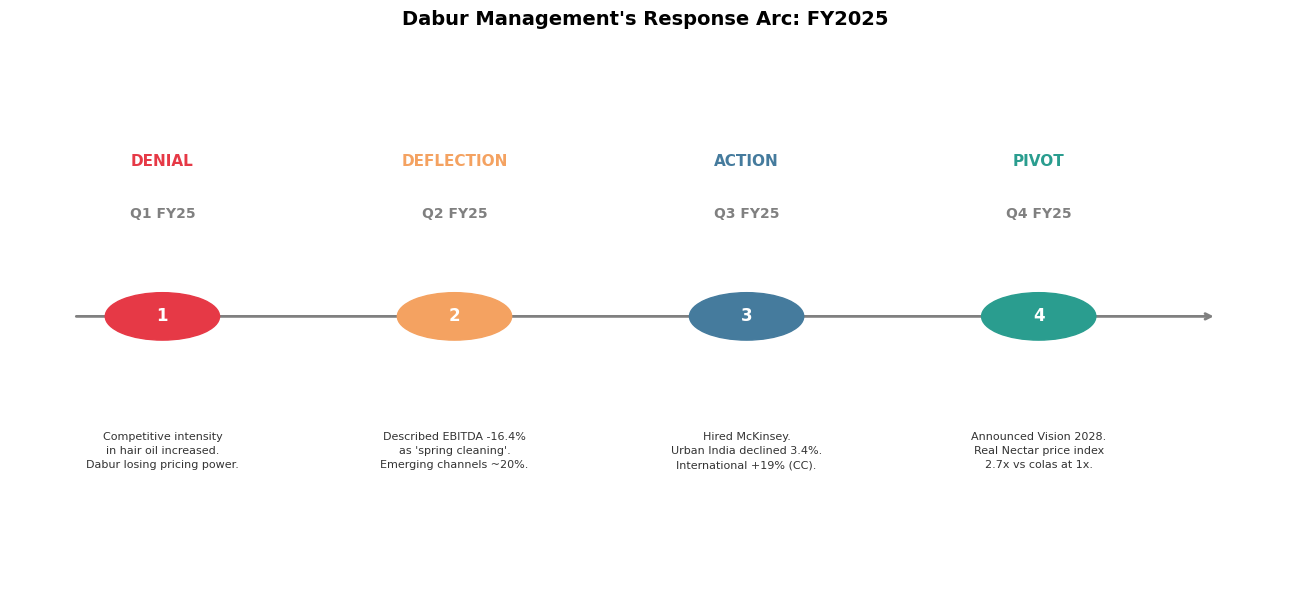

✅ Narrative timeline saved


In [14]:
# Cell 10: Management Narrative Timeline
fig, ax = plt.subplots(figsize=(13, 6))
ax.axis('off')

# Define narrative phases from concall notes
phases = [
    ("Q1 FY25", "DENIAL", "Competitive intensity\nin hair oil increased.\nDabur losing pricing power.", "#E63946"),
    ("Q2 FY25", "DEFLECTION", "Described EBITDA -16.4%\nas 'spring cleaning'.\nEmerging channels ~20%.", "#F4A261"),
    ("Q3 FY25", "ACTION", "Hired McKinsey.\nUrban India declined 3.4%.\nInternational +19% (CC).", "#457B9D"),
    ("Q4 FY25", "PIVOT", "Announced Vision 2028.\nReal Nectar price index\n2.7x vs colas at 1x.", "#2A9D8F"),
]

# Draw timeline
y = 0.5
ax.annotate('', xy=(0.95, y), xytext=(0.05, y),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2),
            xycoords='axes fraction', textcoords='axes fraction')

for i, (quarter, label, detail, color) in enumerate(phases):
    x = 0.12 + i * 0.23

    # Circle marker
    circle = plt.Circle((x, y), 0.045, color=color, transform=ax.transAxes,
                         clip_on=False, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, str(i+1), ha='center', va='center', fontsize=12,
            fontweight='bold', color='white', transform=ax.transAxes, zorder=4)

    # Quarter label above
    ax.text(x, y + 0.18, quarter, ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='gray', transform=ax.transAxes)

    # Phase label
    ax.text(x, y + 0.28, label, ha='center', va='bottom', fontsize=11,
            fontweight='bold', color=color, transform=ax.transAxes)

    # Detail below
    ax.text(x, y - 0.22, detail, ha='center', va='top', fontsize=8,
            color='#333333', transform=ax.transAxes, linespacing=1.5)

ax.set_title("Dabur Management's Response Arc: FY2025", fontsize=14,
             fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('management_narrative.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Narrative timeline saved")

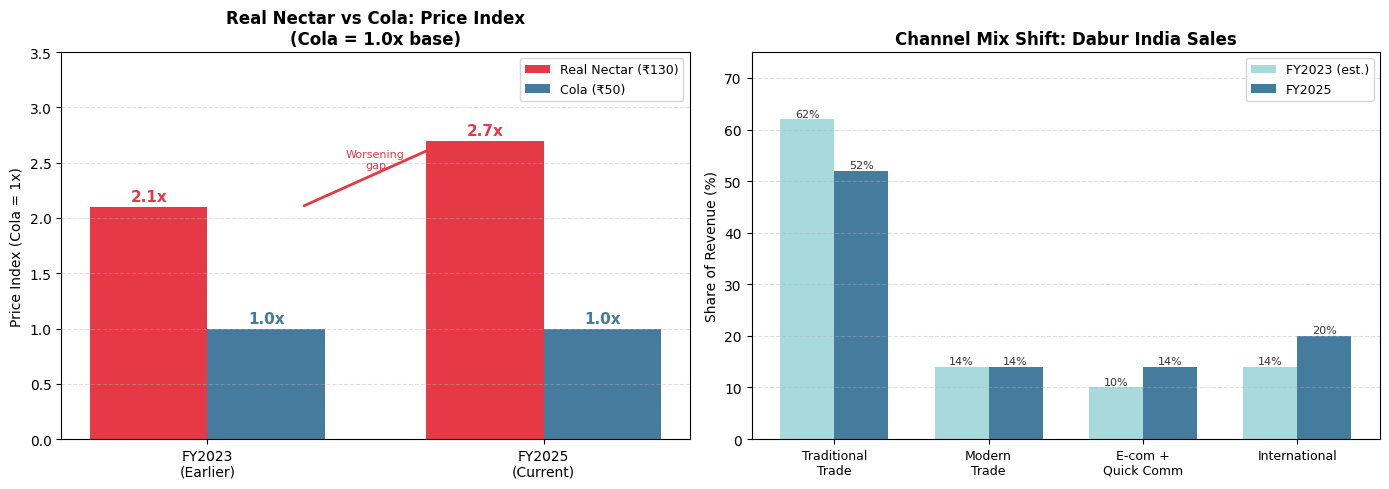

✅ Pricing & channel chart saved


In [15]:
# Cell 11: Beverages Pricing Crisis Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Price index comparison ---
ax1 = axes[0]
categories = ['FY2023\n(Earlier)', 'FY2025\n(Current)']
real_nectar_index = [2.1, 2.7]
cola_index        = [1.0, 1.0]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, real_nectar_index, width, label='Real Nectar (₹130)', color='#E63946')
bars2 = ax1.bar(x + width/2, cola_index,        width, label='Cola (₹50)',          color='#457B9D')

ax1.set_title("Real Nectar vs Cola: Price Index\n(Cola = 1.0x base)", fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=10)
ax1.set_ylabel("Price Index (Cola = 1x)")
ax1.legend(fontsize=9)
ax1.set_ylim(0, 3.5)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Annotate
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height()}x', ha='center', fontsize=11, fontweight='bold', color='#E63946')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height()}x', ha='center', fontsize=11, fontweight='bold', color='#457B9D')

# Add arrow showing worsening
ax1.annotate('', xy=(0.72, 2.7), xytext=(0.28, 2.1),
             arrowprops=dict(arrowstyle='->', color='#E63946', lw=2))
ax1.text(0.5, 2.45, 'Worsening\ngap', ha='center', fontsize=8, color='#E63946')

# --- Right: Channel Mix shift ---
ax2 = axes[1]
channels   = ['Traditional\nTrade', 'Modern\nTrade', 'E-com +\nQuick Comm', 'International']
fy23_share = [62, 14, 10, 14]
fy25_share = [52, 14, 14, 20]   # emerging channels now ~24% India, intl grew

x2 = np.arange(len(channels))
bars3 = ax2.bar(x2 - width/2, fy23_share, width, label='FY2023 (est.)', color='#A8DADC')
bars4 = ax2.bar(x2 + width/2, fy25_share, width, label='FY2025',        color='#457B9D')

ax2.set_title("Channel Mix Shift: Dabur India Sales", fontsize=12, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(channels, fontsize=9)
ax2.set_ylabel("Share of Revenue (%)")
ax2.legend(fontsize=9)
ax2.set_ylim(0, 75)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

for bars in [bars3, bars4]:
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height()}%', ha='center', fontsize=8, color='#333')

plt.tight_layout()
plt.savefig('pricing_channels.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pricing & channel chart saved")

In [16]:
# Cell 12: Master Findings Summary
print("=" * 65)
print("   DABUR INDIA CASE STUDY — PHASE 3 KEY FINDINGS SUMMARY")
print("=" * 65)

findings = [
    ("1. Revenue Growth", f"Dabur +13.4% over 3 yrs vs Marico +48.8% — 3.6x slower"),
    ("2. Margin Gap",     f"Dabur avg OPM 18.4% vs HUL 23.6% — 5pt structural gap"),
    ("3. Margin Vol.",    f"Dabur OPM range 6% vs HUL range 1% — weak pricing power"),
    ("4. Foods Decline",  f"Foods peaked ₹1,710 Cr (FY23), fell to ₹1,600 Cr (FY25)"),
    ("5. Core Stagnant",  f"Consumer Care: ₹6,185 Cr (FY21) → ₹7,295 Cr (FY25) = +18% in 5yrs"),
    ("6. Urban Collapse", f"Urban FMCG growth: 11% (Q1 FY24) → 2.8% (Q2 FY25)"),
    ("7. Beverages",      f"Real Nectar price index vs cola worsened: 2.1x → 2.7x"),
    ("8. Mgmt Arc",       f"Denial (Q1) → Deflection (Q2) → McKinsey (Q3) → Vision 2028 (Q4)"),
    ("9. Channel Shift",  f"Emerging channels (ecom+QC) now ~24% of India sales"),
    ("10. Recovery?",     f"YoY revenue recovering (+7.3% Mar-26) but OPM back to low 15%"),
]

for title, finding in findings:
    print(f"\n  {title}")
    print(f"  → {finding}")

print("\n" + "=" * 65)
print("  Phase 3 Analysis Complete ✅")
print("=" * 65)

   DABUR INDIA CASE STUDY — PHASE 3 KEY FINDINGS SUMMARY

  1. Revenue Growth
  → Dabur +13.4% over 3 yrs vs Marico +48.8% — 3.6x slower

  2. Margin Gap
  → Dabur avg OPM 18.4% vs HUL 23.6% — 5pt structural gap

  3. Margin Vol.
  → Dabur OPM range 6% vs HUL range 1% — weak pricing power

  4. Foods Decline
  → Foods peaked ₹1,710 Cr (FY23), fell to ₹1,600 Cr (FY25)

  5. Core Stagnant
  → Consumer Care: ₹6,185 Cr (FY21) → ₹7,295 Cr (FY25) = +18% in 5yrs

  6. Urban Collapse
  → Urban FMCG growth: 11% (Q1 FY24) → 2.8% (Q2 FY25)

  7. Beverages
  → Real Nectar price index vs cola worsened: 2.1x → 2.7x

  8. Mgmt Arc
  → Denial (Q1) → Deflection (Q2) → McKinsey (Q3) → Vision 2028 (Q4)

  9. Channel Shift
  → Emerging channels (ecom+QC) now ~24% of India sales

  10. Recovery?
  → YoY revenue recovering (+7.3% Mar-26) but OPM back to low 15%

  Phase 3 Analysis Complete ✅
